# CACE-LOREM (`fit-cace-LOREM-now.py`) 训练诊断分析

本 notebook 用于分析：
- 每个 epoch 的电荷统计（`std(q)`、`mean(|q|)`）
- 长程贡献占比（`||F_long||/||F_total||`、`E_long/E_total`）
- `lr_weight`（长程分支权重）变化是否带来收益

数据来源：
- 训练日志：`fit-cumulene/log_59.out`
- 诊断 CSV：`fit-cumulene/loss_data/CACE_LOREM_MP2_now/diagnostics_*.csv`


In [2]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True


In [3]:
# ---- 路径配置 ----
FIT_DIR = Path('/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-LOREM/fit-cumulene')
LOG_PATH = FIT_DIR / 'log_59.out'
NOW_DIR = FIT_DIR / 'loss_data' / 'CACE_LOREM_MP2_now'

assert FIT_DIR.exists(), f'fit 目录不存在: {FIT_DIR}'
assert LOG_PATH.exists(), f'日志不存在: {LOG_PATH}'
assert NOW_DIR.exists(), f'输出目录不存在: {NOW_DIR}'

diag_csvs = sorted(NOW_DIR.glob('diagnostics_*.csv'))
print('diagnostics csv files:')
for p in diag_csvs:
    print(' -', p.name)

if not diag_csvs:
    raise FileNotFoundError(f'在 {NOW_DIR} 未找到 diagnostics_*.csv')

latest_csv = max(diag_csvs, key=lambda p: p.stat().st_mtime)
print('\nuse latest:', latest_csv)

df_csv = pd.read_csv(latest_csv)
df_csv.head()


diagnostics csv files:
 - diagnostics_20260420_105210.csv
 - diagnostics_20260420_110106.csv

use latest: /data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-LOREM/fit-cumulene/loss_data/CACE_LOREM_MP2_now/diagnostics_20260420_110106.csv


,global_epoch,stage,stage_epoch,lr_weight,std_q,mean_abs_q,f_long_over_f_total,e_long_over_e_total
0,1,1,1,1.0,0.045671,0.016231,0.000084,3.047687
1,2,1,2,1.0,0.045370,0.016112,0.000074,4.145254
2,3,1,3,1.0,0.047041,0.016776,0.000064,3.859754
3,4,1,4,1.0,0.048273,0.017271,0.000061,4.130004
4,5,1,5,1.0,0.046970,0.016809,0.000056,3.376283


In [4]:
# ---- 从 log_59.out 解析 [Diag] 行（每 epoch 电荷统计） ----
pat = re.compile(
    r"\[Diag\]\s+epoch=(?P<epoch>\d+)\s+stage=(?P<stage>[0-9.]+)\s+"
    r"lr_weight=(?P<lr_weight>[0-9.eE+-]+)\s+"
    r"std\(q\)=(?P<std_q>[0-9.eE+-]+)\s+"
    r"mean\(\|q\|\)=(?P<mean_abs_q>[0-9.eE+-]+)\s+"
    r"\|\|F_long\|\|/\|\|F_total\|\|=(?P<f_ratio>[0-9.eE+-]+)\s+"
    r"E_long/E_total=(?P<e_ratio>[0-9.eE+-]+)"
)

rows = []
for line in LOG_PATH.read_text(encoding='utf-8', errors='ignore').splitlines():
    m = pat.search(line)
    if m:
        d = m.groupdict()
        rows.append({
            'global_epoch': int(d['epoch']),
            'stage_raw': d['stage'],
            'lr_weight': float(d['lr_weight']),
            'std_q': float(d['std_q']),
            'mean_abs_q': float(d['mean_abs_q']),
            'f_long_over_f_total': float(d['f_ratio']),
            'e_long_over_e_total': float(d['e_ratio']),
        })

df_log = pd.DataFrame(rows)
print('parsed diag rows from log:', len(df_log))
df_log.head()


parsed diag rows from log: 500


,global_epoch,stage_raw,lr_weight,std_q,mean_abs_q,f_long_over_f_total,e_long_over_e_total
0,1,1.1,1.0,0.045671,0.016231,0.000084,3.047687
1,2,1.2,1.0,0.045370,0.016112,0.000074,4.145254
2,3,1.3,1.0,0.047041,0.016776,0.000064,3.859754
3,4,1.4,1.0,0.048273,0.017271,0.000061,4.130004
4,5,1.5,1.0,0.046970,0.016809,0.000056,3.376283


In [5]:
# ---- 统一使用一份“每 epoch 诊断表” ----
# 优先用 log 解析结果（通常更完整），否则退回 csv
if len(df_log) > 0:
    df = df_log.sort_values('global_epoch').reset_index(drop=True)
    src = 'log_59.out'
else:
    df = df_csv.sort_values('global_epoch').reset_index(drop=True)
    src = latest_csv.name

print('analysis source =', src)
print('epochs =', int(df['global_epoch'].min()), '->', int(df['global_epoch'].max()), ', rows =', len(df))
print('unique lr_weight =', sorted(df['lr_weight'].unique().tolist()))
df.describe(include='all')


analysis source = log_59.out
epochs = 1 -> 500 , rows = 500
unique lr_weight = [1.0]


,global_epoch,stage_raw,lr_weight,std_q,mean_abs_q,f_long_over_f_total,e_long_over_e_total
count,500.000000,500,500.0,500.000000,500.000000,500.000000,500.000000
unique,NaN,500,NaN,NaN,NaN,NaN,NaN
top,NaN,4.100,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN
mean,250.500000,NaN,1.0,0.030264,0.011178,0.000053,4.068729
std,144.481833,NaN,0.0,0.002268,0.000759,0.000002,0.093639
min,1.000000,NaN,1.0,0.029493,0.010940,0.000048,3.047687
25%,125.750000,NaN,1.0,0.029839,0.011037,0.000052,4.085150
50%,250.500000,NaN,1.0,0.029857,0.011037,0.000052,4.088893
75%,375.250000,NaN,1.0,0.029858,0.011038,0.000052,4.089746


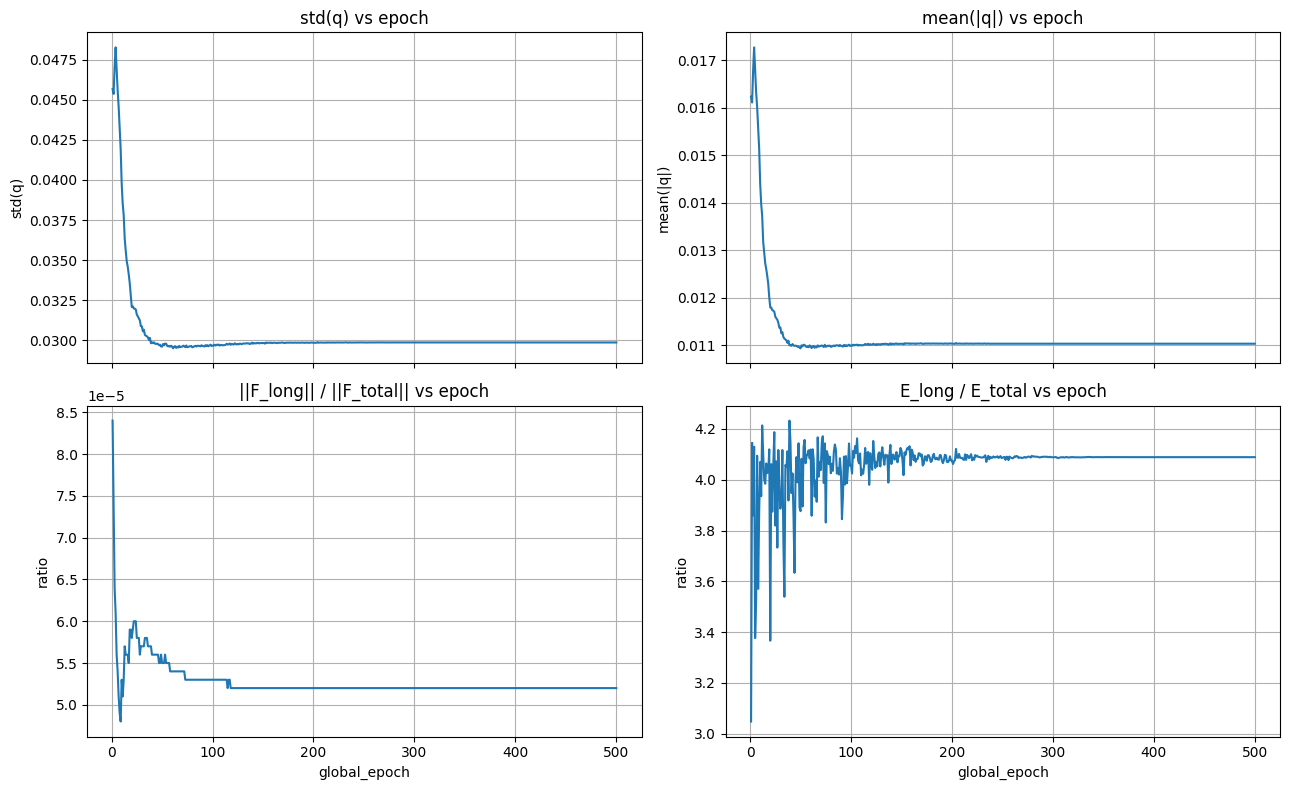

In [6]:
# ---- 每 epoch 电荷统计与长程占比曲线 ----
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

axes[0, 0].plot(df['global_epoch'], df['std_q'])
axes[0, 0].set_title('std(q) vs epoch')
axes[0, 0].set_ylabel('std(q)')

axes[0, 1].plot(df['global_epoch'], df['mean_abs_q'])
axes[0, 1].set_title('mean(|q|) vs epoch')
axes[0, 1].set_ylabel('mean(|q|)')

axes[1, 0].plot(df['global_epoch'], df['f_long_over_f_total'])
axes[1, 0].set_title('||F_long|| / ||F_total|| vs epoch')
axes[1, 0].set_xlabel('global_epoch')
axes[1, 0].set_ylabel('ratio')

axes[1, 1].plot(df['global_epoch'], df['e_long_over_e_total'])
axes[1, 1].set_title('E_long / E_total vs epoch')
axes[1, 1].set_xlabel('global_epoch')
axes[1, 1].set_ylabel('ratio')

plt.tight_layout()
plt.show()


In [7]:
# ---- “增大长程权重是否有用”分析 ----
weights = sorted(df['lr_weight'].unique().tolist())
print('observed lr_weight values:', weights)

if len(weights) <= 1:
    print('\n结论（当前这次训练）：')
    print(' - lr_weight 在本次运行中是常数，无法从同一条曲线做“增大权重是否有用”的因果比较。')
    print(' - 你仍然可以看电荷/长程占比是否随 epoch 抬升，用于判断长程分支是否在学习。')
else:
    g = df.groupby('lr_weight')[['std_q','mean_abs_q','f_long_over_f_total','e_long_over_e_total']].agg(['mean','median','max'])
    display(g)
    print('\n提示：若 lr_weight 增大时 std(q) 与长程占比同步上升，且验证误差不恶化，通常说明增大有帮助。')


observed lr_weight values: [1.0]

结论（当前这次训练）：
 - lr_weight 在本次运行中是常数，无法从同一条曲线做“增大权重是否有用”的因果比较。
 - 你仍然可以看电荷/长程占比是否随 epoch 抬升，用于判断长程分支是否在学习。


In [8]:
# ---- 可选：跨多个 diagnostics 文件做对比（若你后续跑了不同设置） ----
all_diag = sorted((FIT_DIR / 'loss_data').rglob('diagnostics_*.csv'))
print('found diagnostics files:', len(all_diag))

rows = []
for p in all_diag:
    try:
        d = pd.read_csv(p)
        required = {'std_q','mean_abs_q','f_long_over_f_total','e_long_over_e_total','lr_weight'}
        if required.issubset(set(d.columns)) and len(d) > 0:
            rows.append({
                'file': str(p.relative_to(FIT_DIR)),
                'n_rows': len(d),
                'lr_weight_unique': sorted(d['lr_weight'].unique().tolist()),
                'std_q_last': float(d['std_q'].iloc[-1]),
                'f_ratio_last': float(d['f_long_over_f_total'].iloc[-1]),
                'e_ratio_last': float(d['e_long_over_e_total'].iloc[-1]),
            })
    except Exception:
        pass

df_runs = pd.DataFrame(rows)
display(df_runs.sort_values('file'))


found diagnostics files: 2


,file,n_rows,lr_weight_unique,std_q_last,f_ratio_last,e_ratio_last
0,loss_data/CACE_LOREM_MP2_now/diagnostics_20260...,500,[1.0],0.029857,0.000052,4.088894
